<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Box Plots**


Estimated time needed: **45** minutes


## Objectives


In this lab you will perform the following:


-   Visualize the distribution of data.

-   Visualize the relationship between two features.

-   Visualize data composition and comparisons using box plots.


**Install the needed libraries**


In [2]:
!pip install pandas

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 147.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 168.8 MB/s eta 0:00:00


In [27]:
!pip install matplotlib

In [9]:
!pip install numpy
!pip install seaborn

In [30]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [13]:
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DA0321EN-SkillsNetwork/LargeData/m2_survey_data.csv"
df = pd.read_csv(dataset_url)

In [14]:
df.head()

,Respondent,MainBranch,Hobbyist,OpenSourcer,OpenSource,Employment,Country,Student,EdLevel,UndergradMajor,...,WelcomeChange,SONewContent,Age,Gender,Trans,Sexuality,Ethnicity,Dependents,SurveyLength,SurveyEase
0,4,I am a developer by profession,No,Never,The quality of OSS and closed source software ...,Employed full-time,United States,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,22.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Easy
1,9,I am a developer by profession,Yes,Once a month or more often,The quality of OSS and closed source software ...,Employed full-time,New Zealand,No,Some college/university study without earning ...,"Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,NaN,23.0,Man,No,Bisexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
2,13,I am a developer by profession,Yes,Less than once a month but more than once per ...,"OSS is, on average, of HIGHER quality than pro...",Employed full-time,United States,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)","Computer science, computer engineering, or sof...",...,Somewhat more welcome now than last year,Tech articles written by other developers;Cour...,28.0,Man,No,Straight / Heterosexual,White or of European descent,Yes,Appropriate in length,Easy
3,16,I am a developer by profession,Yes,Never,The quality of OSS and closed source software ...,Employed full-time,United Kingdom,No,"Master’s degree (MA, MS, M.Eng., MBA, etc.)",NaN,...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,26.0,Man,No,Straight / Heterosexual,White or of European descent,No,Appropriate in length,Neither easy nor difficult
4,17,I am a developer by profession,Yes,Less than once a month but more than once per ...,The quality of OSS and closed source software ...,Employed full-time,Australia,No,"Bachelor’s degree (BA, BS, B.Eng., etc.)","Computer science, computer engineering, or sof...",...,Just as welcome now as I felt last year,Tech articles written by other developers;Indu...,29.0,Man,No,Straight / Heterosexual,Hispanic or Latino/Latina;Multiracial,No,Appropriate in length,Easy


## Visualizing Data


### Task 1: Visualizing the Distribution of Data


**1. Box Plot of `CompTotal` (Total Compensation)**


Use a box plot to analyze the distribution and outliers in total compensation.


Text(0.5, 0, 'Total Compensation')

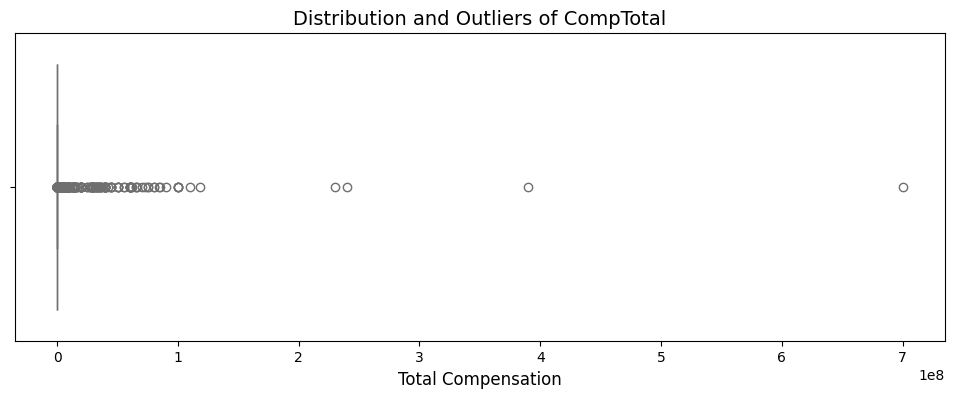

In [31]:
comp_df = df['CompTotal']

# Boxplot

plt.figure(figsize=(12, 4))
sns.boxplot(x=comp_df, color='skyblue')

# Add labels and title
plt.title('Distribution and Outliers of CompTotal', fontsize=14)
plt.xlabel('Total Compensation', fontsize=12)

In [ ]:
# As we can see there are extremely high values of Total Compensation. These values are considered outliers and should be treated as such.
# We will calculate the IQR of CompTotal and create a cleaner data subset of CompTotal but without the outliers.

In [41]:
comp_df = comp_df.dropna()

In [44]:
comp_df.isnull().sum()

np.int64(0)

In [45]:
# Quartiles
Q1 = comp_df.quantile(0.25)
Q3 = comp_df.quantile(0.75)

# IQR
IQR = Q3 - Q1

print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)

Q1: 25000.0
Q3: 120000.0
IQR: 95000.0


In [46]:
# Define bounds
lower_bound = max(0, Q1 - 1.5 * IQR)
upper_bound = Q3 + 1.5 * IQR

print('Lower Bound:', lower_bound)
print('Upper Bound:', upper_bound)

Lower Bound: 0
Upper Bound: 262500.0


In [47]:
# In this case we will accept any total compensation up to 262500. If we wanted to keep higher compensations in the analysis we would simply modify the upper bound.

In [48]:
outliers = comp_df[(comp_df < lower_bound) | (comp_df > upper_bound)]

In [49]:
print('Number of outliers:', len(outliers))

Number of outliers: 1120


In [50]:
# We will drop the outliers from our data, so that they are excluded from the analysis
clean_comp_df = comp_df[(comp_df >= lower_bound) & (comp_df <= upper_bound)]

In [51]:
print("Original size:", len(comp_df))
print("Cleaned size:", len(clean_comp_df))
print("Removed outliers:", len(comp_df) - len(clean_comp_df))
print("After handling outliers, the new number of different values in the CompTotal is:", clean_comp_df.value_counts().shape[0])

Original size: 10589
Cleaned size: 9469
Removed outliers: 1120
After handling outliers, the new number of different values in the CompTotal is: 1163


**2. Box Plot of Age (converted to numeric values)**


Convert the `Age` column into numerical values and visualize the distribution.


In [56]:
# First we check the data type of 'Age'
print('The data type of "Age" column is:', df['Age'].dtype)

The data type of "Age" column is: float64


In [57]:
age_df = df['Age'].dropna()

Text(0.5, 0, 'Age (Years)')

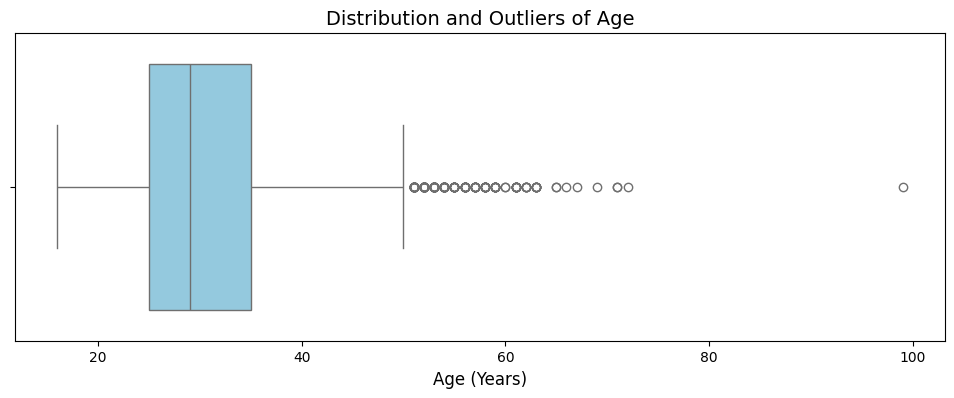

In [59]:
# Boxplot
plt.figure(figsize=(12, 4))
sns.boxplot(x=age_df, color='skyblue')

# 3. Add labels and title
plt.title('Distribution and Outliers of Age', fontsize=14)
plt.xlabel('Age (Years)', fontsize=12)

In [62]:
print('Someone has stated that he is', int(max(age_df)) , 'years old!')

Someone has stated that he is 99 years old!


### Task 2: Visualizing Relationships in Data


**1. Box Plot of `CompTotal` Grouped by Age Groups:**


Visualize the distribution of compensation across different age groups.


In [78]:
cta_df = df[['CompTotal','Age']]
cta_df = cta_df.dropna()

In [79]:
# Previously we found that the upper bound for CompTotal is 262500.
# So we will only include rows that have CompTotal values less than 263001.

In [80]:
cta_df = cta_df[cta_df['CompTotal'] < 262501]

In [81]:
# Create age groups (bins)
bins = [0, 25, 35, 45, 55, 65, 100]
labels = ['<25', '25-34', '35-44', '45-54', '55-64', '65+']

cta_df['AgeGroup'] = pd.cut(cta_df['Age'], bins=bins, labels=labels)

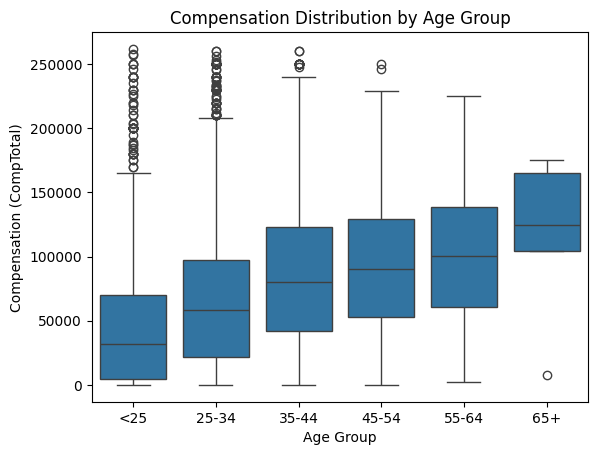

In [82]:
# Boxplot
plt.figure()
sns.boxplot(x='AgeGroup', y='CompTotal', data=cta_df)

plt.xlabel('Age Group')
plt.ylabel('Compensation (CompTotal)')
plt.title('Compensation Distribution by Age Group')

plt.show()

**2. Box Plot of `CompTotal` Grouped by Job Satisfaction (`JobSat`):**


Examine how compensation varies based on job satisfaction levels.


In [85]:
# Select relevant columns and clean
ctj_df = df[['CompTotal', 'JobSat']].dropna()

In [86]:
ctj_df = ctj_df[ctj_df['CompTotal'] < 262501]

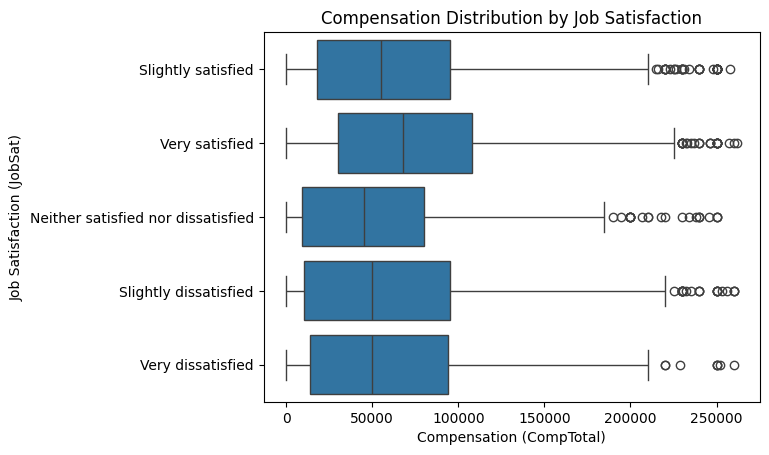

In [88]:
# Boxplot
plt.figure()
sns.boxplot(x='CompTotal', y='JobSat', data=ctj_df)

plt.xlabel('Compensation (CompTotal)')
plt.ylabel('Job Satisfaction (JobSat)')
plt.title('Compensation Distribution by Job Satisfaction')

plt.show()

**3. Box Plot of `CompTotal` for the Top 5 Countries:**


Analyze compensation across respondents from the top 5 countries.


In [97]:
comp_country_df = df[['CompTotal', 'Country']].dropna()

In [98]:
comp_country_df = comp_country_df[comp_country_df['CompTotal'] < 262501]

In [99]:
# Get top 5 countries by count
top5_countries = comp_country_df['Country'].value_counts().nlargest(5).index

In [100]:
# Filter dataset
comp_country_df_top5 = comp_country_df[comp_country_df['Country'].isin(top5_countries)]

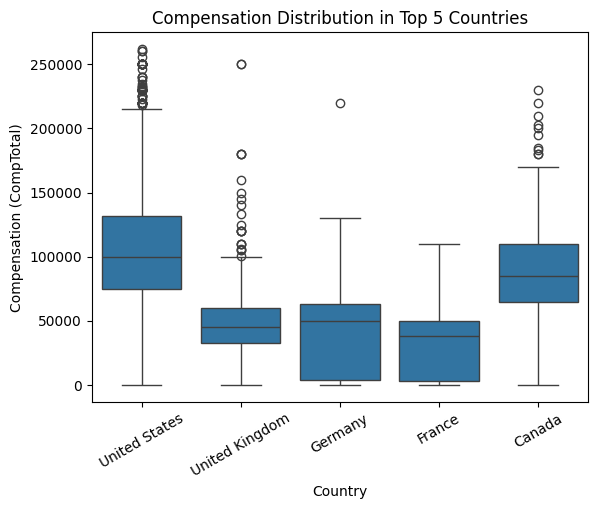

In [101]:
# BoxPlot
plt.figure()
sns.boxplot(x='Country', y='CompTotal', data=comp_country_df_top5)

plt.xlabel('Country')
plt.ylabel('Compensation (CompTotal)')
plt.title('Compensation Distribution in Top 5 Countries')

plt.xticks(rotation=30)
plt.show()

### Task 3: Visualizing Comparison of Data


**1. Box Plot of CompTotal Across Employment Types:**


Analyze compensation for different employment types.


In [106]:
comp_emp_df = df[['CompTotal','Employment']]
comp_emp_df = comp_emp_df.dropna()

In [107]:
comp_emp_df = comp_emp_df[comp_emp_df['CompTotal'] < 262501]

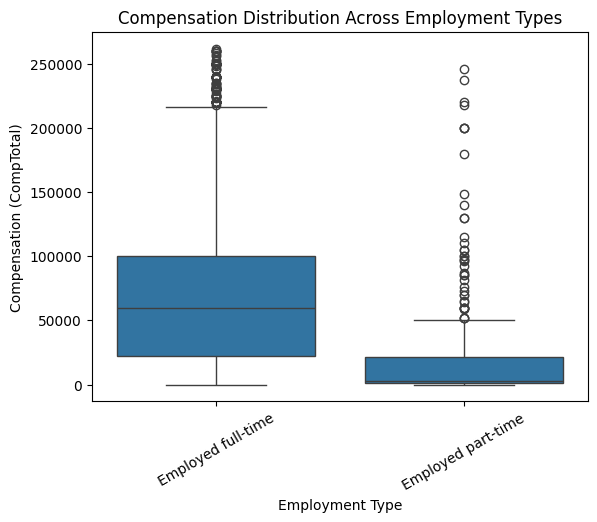

In [108]:
# Boxplot
plt.figure()
sns.boxplot(x='Employment', y='CompTotal', data=comp_emp_df)

plt.xlabel('Employment Type')
plt.ylabel('Compensation (CompTotal)')
plt.title('Compensation Distribution Across Employment Types')

plt.xticks(rotation=30)
plt.show()

**2. Box Plot of `YearsCodePro` by Job Satisfaction (`JobSat`):**


Examine the distribution of professional coding years by job satisfaction levels.


In [115]:
code_js_df = df[['YearsCodePro','JobSat']]
code_js_df = code_js_df.dropna()

In [ ]:
df[

In [116]:
code_js_df['YearsCodePro'] = pd.to_numeric(code_js_df['YearsCodePro'], errors='coerce')
code_js_df = code_js_df.dropna()

In [118]:
order = [
    'Very dissatisfied',
    'Slightly dissatisfied',
    'Neither satisfied nor dissatisfied',
    'Slightly satisfied',
    'Very satisfied'
]

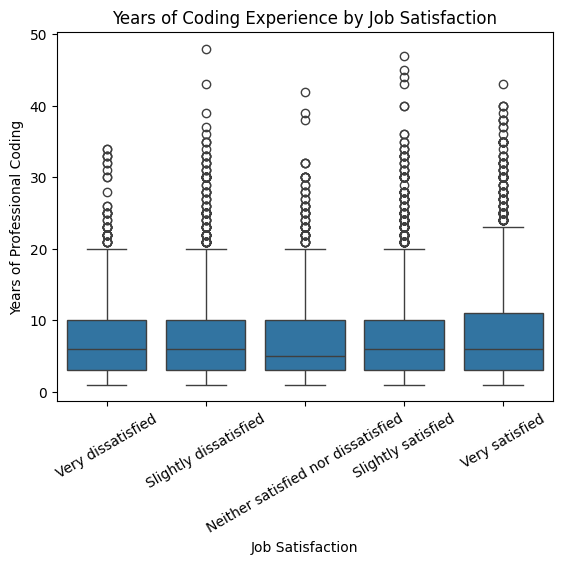

In [119]:
# Boxplot
plt.figure()
sns.boxplot(x='JobSat', y='YearsCodePro', data=code_js_df, order=order)

plt.xlabel('Job Satisfaction')
plt.ylabel('Years of Professional Coding')
plt.title('Years of Coding Experience by Job Satisfaction')

plt.xticks(rotation=30)
plt.show()

## Summary


In this lab, you used box plots to visualize various aspects of the dataset, focusing on:

- Visualize distributions of compensation and age.

- Explore relationships between compensation, job satisfaction, and professional coding experience.

- Analyze data composition across developer roles and countries.

- Compare compensation across employment types and satisfaction levels.

Box plots provided clear insights into the spread, outliers, and central tendencies of various features in the dataset.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
